**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 6**
Ingeniería de características (FE)

---

*   NOMBRE: Darío Martín Romero Cruz
*   MATRÍCULA: A01841015

En esta actividad trabajarás con el archivo `computer_prices.csv`, basado en un conjunto de datos sobre características técnicas y especificaciones de computadoras portátiles y de escritorio, disponible en Kaggle.

Los datos fueron recopilados para analizar el rendimiento y el precio de los dispositivos, e incluyen información sobre hardware, almacenamiento, conectividad y otras especificaciones técnicas. Los indicadores incluidos son:

* `device_type`: Tipo de dispositivo (ej. laptop, desktop)
* `brand`: Marca del dispositivo
* `model`: Modelo del dispositivo
* `release_year`: Año de lanzamiento del dispositivo
* `os`: Sistema operativo instalado
* `form_factor`: Factor de forma o diseño del dispositivo (ej. laptop, ultrabook, desktop tower)
* `cpu_brand`: Marca del procesador
* `cpu_tier`: Nivel o gama del procesador, ordinal del 1 al 6 según desempeño
* `cpu_cores`: Número de núcleos del procesador
* `cpu_threads`: Número de hilos de ejecución del procesador
* `gpu_brand`: Marca de la tarjeta gráfica
* `gpu_model`: Modelo específico de la tarjeta gráfica
* `gpu_tier`: Nivel o gama de la GPU, ordinal del 1 al 6 según desempeño
* `vram_gb`: Memoria de video de la GPU en gigabytes
* `ram_gb`: Memoria RAM del dispositivo en gigabytes
* `storage_type`: Tipo de almacenamiento (ej. HDD, SSD)
* `storage_gb`: Capacidad de almacenamiento en gigabytes
* `storage_drive_count`: Número de unidades de almacenamiento instaladas
* `display_type`: Tipo de pantalla (ej. IPS, TN, OLED)
* `charger_watts`: Potencia del cargador (en watts) para laptops
* `psu_watts`: Potencia de la fuente de poder (en watts) para desktops
* `wifi`: Estándar de conectividad Wi-Fi (ej. Wi-Fi 5, 6, 6E, 7)
* `bluetooth`: Versión de Bluetooth
* `weight_kg`: Peso del dispositivo en kilogramos
* `warranty_months`: Meses de garantía del dispositivo
* `price`: Precio del dispositivo. Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo.

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [ ]:
# Instalar las bibliotecas necesarias
#!pip install category_encoders

In [4]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from scipy.stats import probplot
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import FunctionTransformer, PowerTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from category_encoders.binary import BinaryEncoder

1. Descarga el archivo: `computer_prices.csv` y guarda, en un dataframe (`compu_df`), todos sus registros.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Determina la cantidad de valores únicos por columna.
* Elimina las variables:
  * `model`: Debido a su altísima cardinalidad, lo que dificulta su uso en análisis y modelado.
  * `cpu_model`: Además de su elevada cardinalidad, su información ya está representada de manera implícita en otras variables como: `cpu_tier`, `cpu_cores` y `cpu_threads`

In [5]:
compu_df = pd.read_csv('computer_prices.csv', sep = ',') #Leer informacion

#Identificar columnas numericas y no numericas
ColNum = list(compu_df.dtypes.loc[compu_df.dtypes.astype(str).isin(['int64', 'float64', 'int', 'float'])].index) #Lista de columnas numericas
ColNoNum = list(compu_df.dtypes.loc[compu_df.dtypes.astype(str).isin(['string', 'object', 'category'])].index) #Lista de columnas string

compu_unique = compu_df.nunique() #Identificar valores unicos

#Imprimir resultados
print('Tipos de datos de nuestro archivo:\n')
compu_df.info()

print(f'\nTotal de filas: {compu_df.shape[0]:,}')
print(f'Total de columnas: {compu_df.shape[1]:,}')

print(f'  > Numericas: {len(ColNum)}')
print(f'  > No numericas: {len(ColNoNum)}')

#Mostrar valores unicos por columnas, se decide separar para hacer mas facil el siguiente punto
print('\nCantidad de valores unicos por columnas numericas:')
for Col in ColNum:
    print(f'  > {Col}: {compu_unique[Col]:,}')

print('\nCantidad de valores unicos por columnas no numericas:')
for Col in ColNoNum:
    print(f'  > {Col}: {compu_unique[Col]:,}')

#Eliminar columnas model y cpu_model
compu_df.drop(columns = ['model', 'cpu_model'], inplace = True)
ColNoNum = [Col for Col in ColNoNum if Col not in ['model', 'cpu_model']]
print('\nColumnas eliminadas: model, cpu_model')

Tipos de datos de nuestro archivo:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   device_type          100000 non-null  object 
 1   brand                100000 non-null  object 
 2   model                100000 non-null  object 
 3   release_year         100000 non-null  int64  
 4   os                   100000 non-null  object 
 5   form_factor          100000 non-null  object 
 6   cpu_brand            100000 non-null  object 
 7   cpu_model            100000 non-null  object 
 8   cpu_tier             100000 non-null  int64  
 9   cpu_cores            100000 non-null  int64  
 10  cpu_threads          100000 non-null  int64  
 11  gpu_brand            100000 non-null  object 
 12  gpu_model            100000 non-null  object 
 13  gpu_tier             100000 non-null  int64  
 14  vram_gb              100000 non-n

2. Antes de iniciar con el análisis univariado, verifica si hay valores duplicados y/o faltantes.
* Obtén las estadísticas descriptivas, separado las numéricas y las categóricas. De estas últimas incluye las tablas de frecuencia.
* Genera histogramas para las numéricas y diagramas de barras para las categóricas. Con alta cardinalidad, sólo incluye los 10 valores más frecuentes.

ANALISIS DE LAS VARIABLES NUMERICAS:

Estadistica descriptiva

       release_year   cpu_tier  cpu_cores  cpu_threads   gpu_tier    vram_gb  \
count     100000.00  100000.00  100000.00    100000.00  100000.00  100000.00   
mean        2022.32       3.15      10.52        19.37       2.99       6.15   
std            2.03       1.37       5.04         9.72       1.46       3.96   
min         2018.00       1.00       4.00         4.00       1.00       0.00   
5%          2018.00       1.00       4.00         8.00       1.00       0.00   
50%         2023.00       3.00       8.00        16.00       3.00       6.00   
95%         2025.00       5.00      20.00        36.00       6.00      12.00   
max         2025.00       6.00      28.00        56.00       6.00      16.00   
skew          -0.48       0.17       1.09         1.13       0.29       0.28   
kurt          -0.72      -0.75       1.01         1.30      -0.85      -0.35   

          ram_gb  storage_gb  storage_drive_count  charg

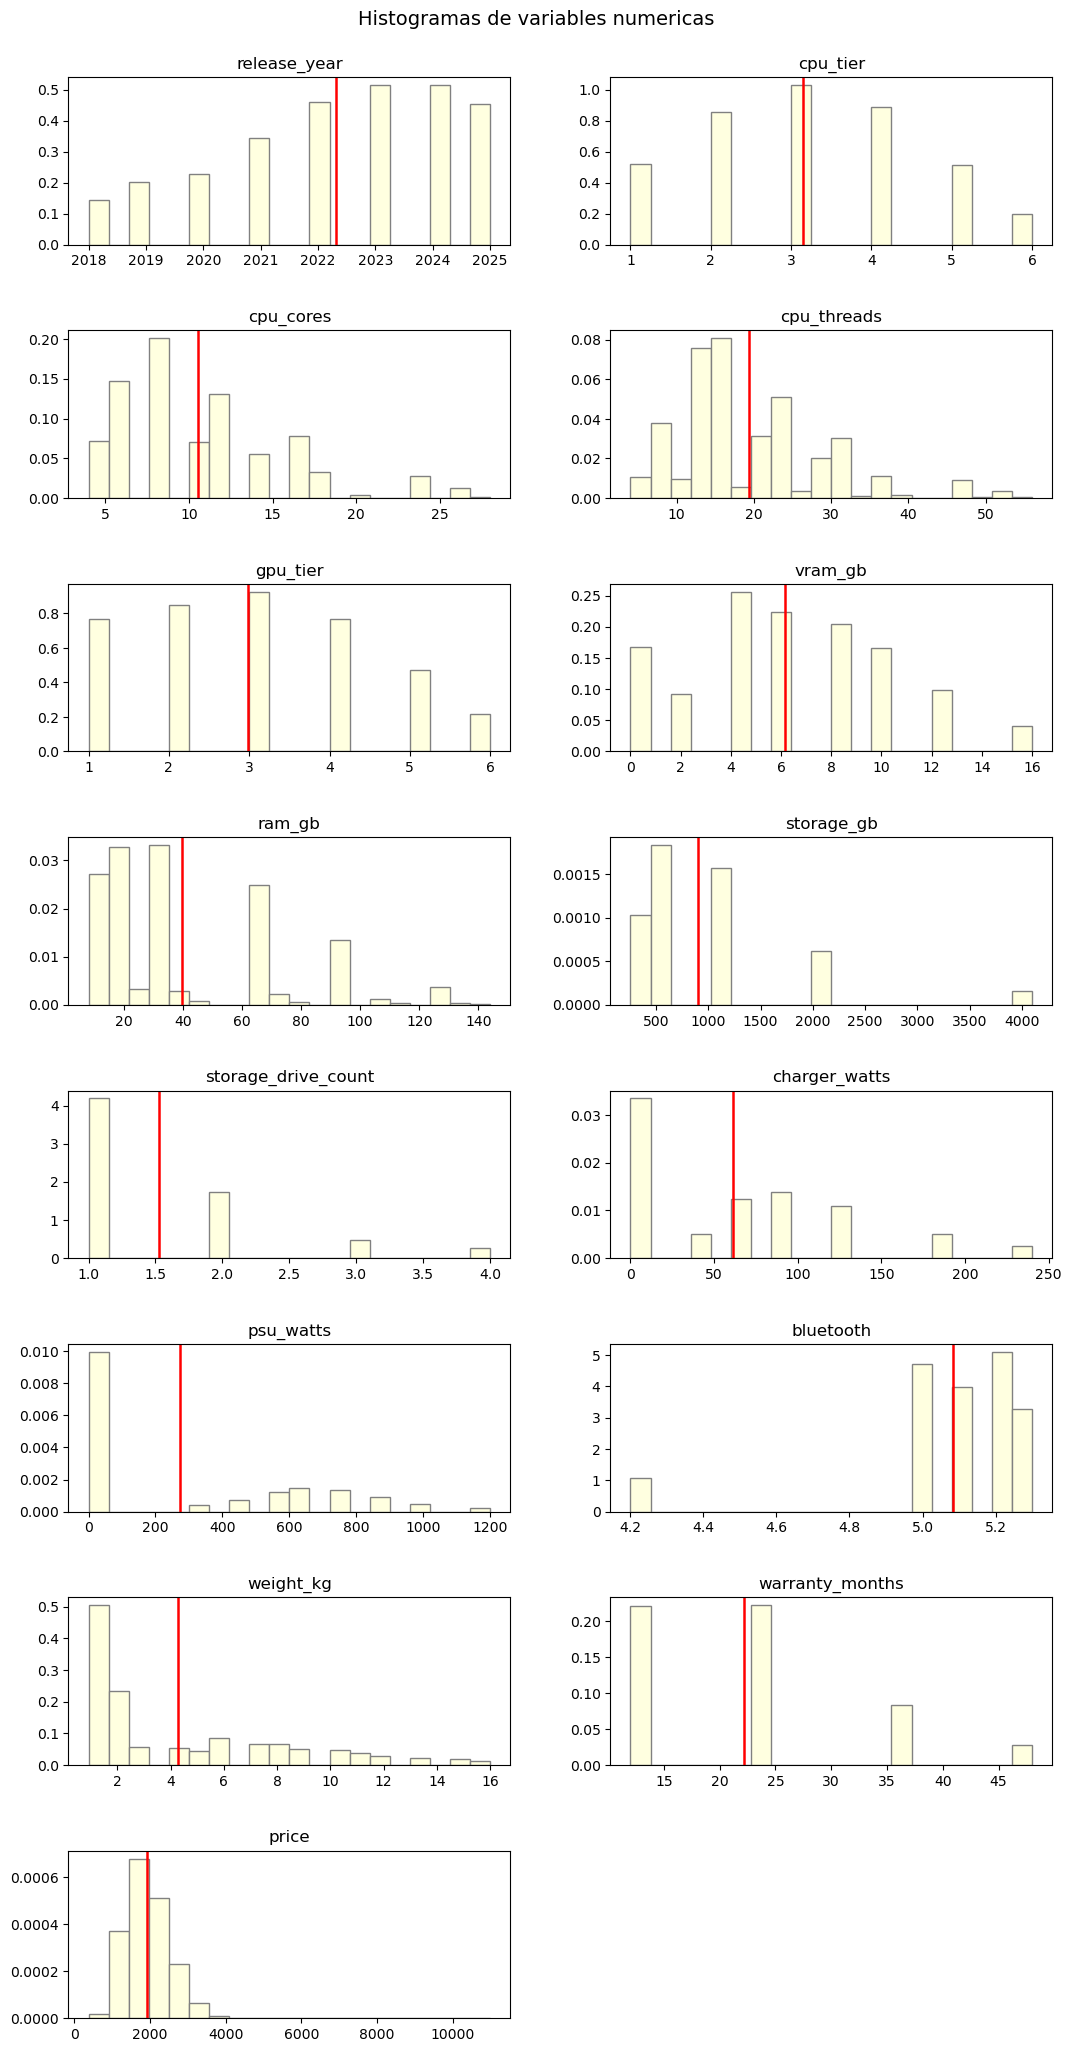



ANALISIS DE LAS VARIABLES CATEGORICAS:

Estadistica descriptiva

       device_type   brand       os form_factor cpu_brand gpu_brand  \
count       100000  100000   100000      100000    100000    100000   
unique           2      10        4          10         3         4   
top         Laptop  Lenovo  Windows  Mainstream     Intel    NVIDIA   
freq         59844   15992    71817       17819     52774     54712   

               gpu_model storage_type display_type     wifi  
count             100000       100000       100000   100000  
unique                49            4            6        4  
top     Apple Integrated         NVMe          LED  Wi-Fi 6  
freq               18922        45059        32000    46149  


Tablas de frecuencia

  > device_type
     Laptop: 59844
     Desktop: 40156

  > brand
     Lenovo: 15992
     HP: 14114
     Dell: 14005
     Apple: 11915
     ASUS: 10159
     Acer: 9925
     Samsung: 8066
     MSI: 7891
     Gigabyte: 4900
     Razer: 3033

  >

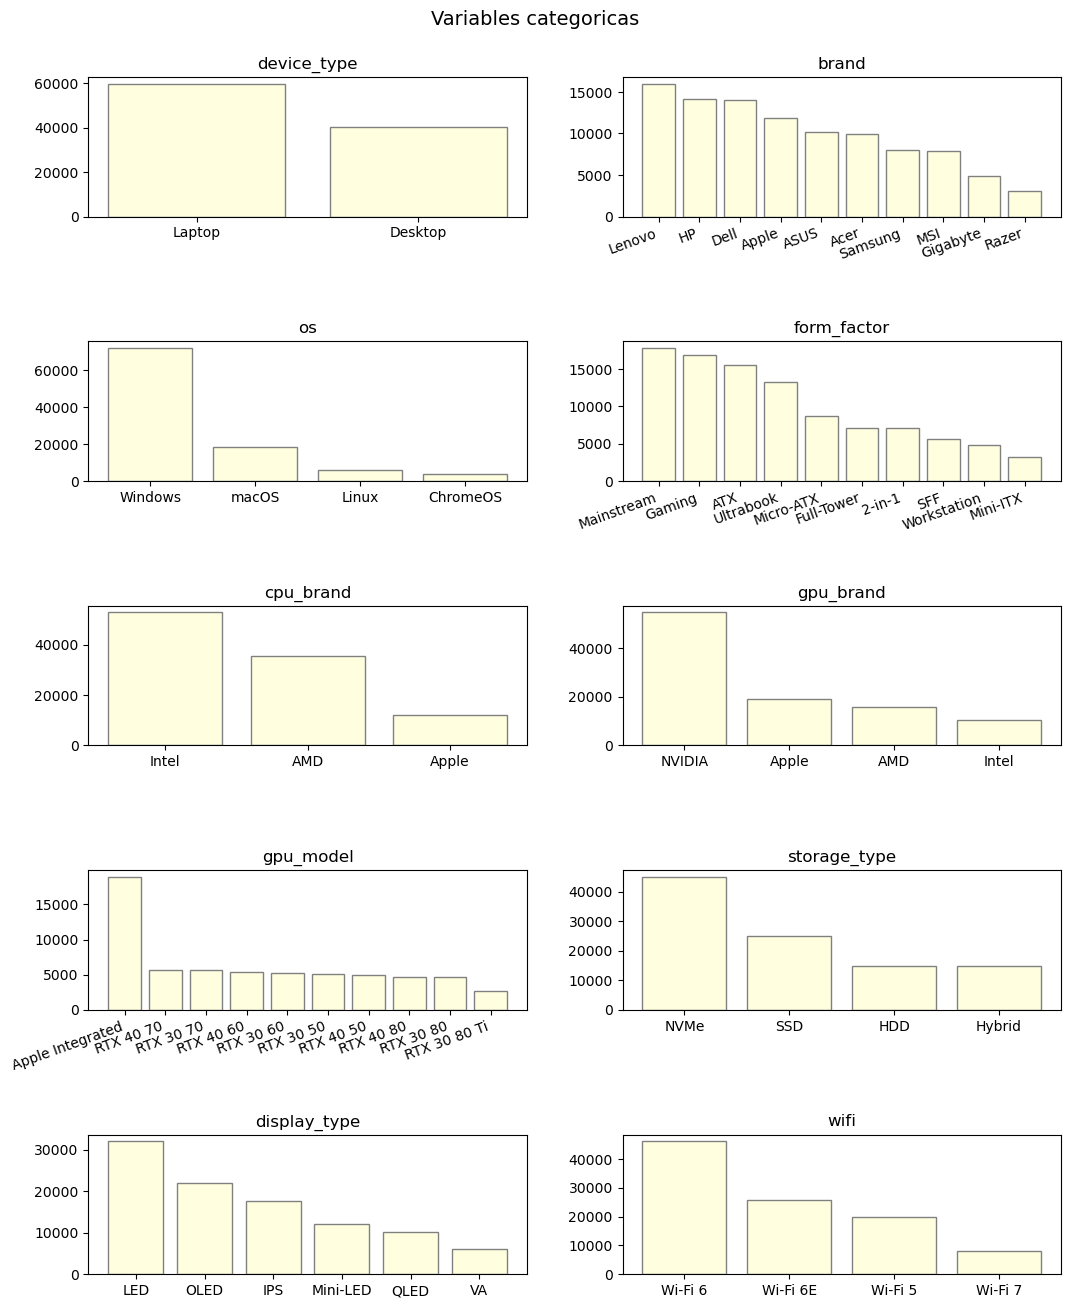

*Variables con mas de 10 categorias: gpu_model


In [6]:
import matplotlib.pyplot as plt
import scipy.stats as stats

#Obtener estadísticas de las columnas numericas-------------
Stat = compu_df[ColNum].describe(percentiles = [0.05, 0.95])
Stat = pd.concat([Stat, compu_df[ColNum].agg(['skew', 'kurt'])]) #Agregar sesgo y curtosis

#Imprimir resultados
print('ANALISIS DE LAS VARIABLES NUMERICAS:\n\nEstadistica descriptiva\n')
print(Stat.round(2))


#Histogramas-------------
print('\nHistogramas:')
Fig1 = plt.figure(figsize = (12, 22))
i = 0

for Col in ColNum:
    i += 1
    Ax = Fig1.add_subplot(8, 2, i)

    #Histograma
    x = compu_df[Col]
    Ax.hist(x, bins = 20, density = True, color = 'lightyellow', edgecolor = 'gray') # Histograma normalizado

    #Media
    Ax.axvline(Stat.loc['mean', Col], color = 'red', ls = '-', lw = 1.8, label = 'Media')

    Ax.set_title(Col)
    #Ax.legend(loc = 'best', fontsize = 'small', framealpha = 0.99)

Fig1.suptitle('Histogramas de variables numericas', fontsize = 14)    
Fig1.tight_layout(pad = 1.0, w_pad = 3, h_pad = 3, rect=[0.05, 0.05, 0.95, 0.98])
plt.show()


#Obtener estadísticas de las columnas categoricas-------------
compu_df[ColNoNum] = compu_df[ColNoNum].astype('category') #Pasa columnas tipo object a categoricas
Stat = compu_df[ColNoNum].describe()

#Imprimir resultados
print('\n\nANALISIS DE LAS VARIABLES CATEGORICAS:\n\nEstadistica descriptiva\n')
print(Stat.round(2))


#Tablas de frecuencia-------------
print('\n\nTablas de frecuencia')
for Col in ColNoNum:
    print(f'\n  > {Col}')
    for i, Row in compu_df[Col].value_counts(dropna = False).reset_index().iterrows():
        print(f'     {Row[Col]}: {Row['count']}')


#Graficas de barra-------------
Fig1 = plt.figure(figsize = (12, 14))
i = 0

cat_long = []
for Col in ColNoNum:
    i += 1
    Ax = Fig1.add_subplot(5, 2, i)

    #Grafico de barras
    Counts = compu_df[Col].value_counts()
    if len(Counts) > 10:
        Counts = Counts.head(10)
        cat_long += [Col]
    
    #Counts.sort_index(inplace = True)

    Ax.bar(Counts.index.astype(str), Counts.values, color = 'lightyellow', edgecolor = 'gray') # Histograma normalizado
    
    Ax.set_title(Col)
    if len(Counts) > 8:
        Ax.tick_params(axis = 'x', rotation = 20)
        for label in Ax.get_xticklabels():
            label.set_ha('right')


Fig1.suptitle('Variables categoricas', fontsize = 14)    
Fig1.tight_layout(pad = 1.0, w_pad = 3, h_pad = 3, rect=[0.05, 0.05, 0.95, 0.98])
plt.show()

print(f'*Variables con mas de 10 categorias: {', '.join(cat_long)}')


3. Dibuja un mapa de calor con la matriz de correlación para las variables numéricas del conjunto de datos.
* Identifica los pares de variables cuya correlación sea superior a 0.9 e imprímelos.
* Reflexiona sobre cuáles variables, de las que se imprimieron, representan de manera general la capacidad del hardware y mantenlas; elimina las demás por aportar información redundante.
* Incluye una breve justificación de tus decisiones.

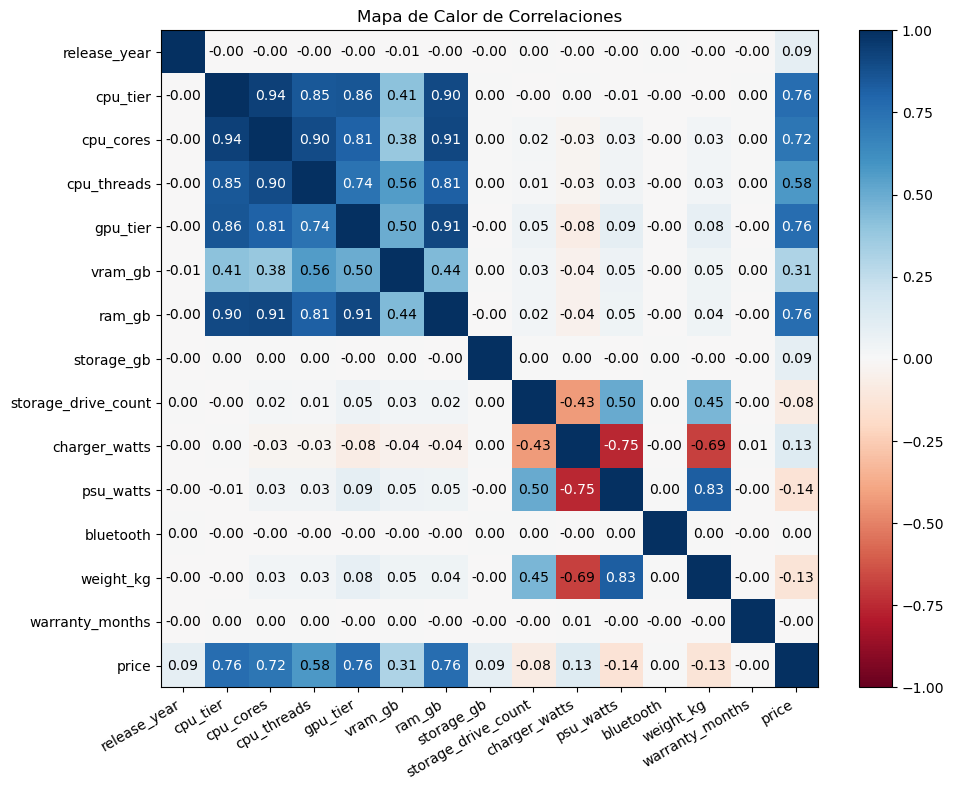


Parejas de variables con alta correlacion:
  > cpu_cores - cpu_tier: 0.9374
  > ram_gb - cpu_cores: 0.9068
  > ram_gb - gpu_tier: 0.9129

           cpu_tier  cpu_cores  gpu_tier  ram_gb
cpu_tier       1.00       0.94      0.86    0.90
cpu_cores      0.94       1.00      0.81    0.91
gpu_tier       0.86       0.81      1.00    0.91
ram_gb         0.90       0.91      0.91    1.00


In [7]:
#Tomar solo columnas numericas y aplicar correlación de Pearson
Corr = compu_df[ColNum].corr(method = 'pearson')
nCorr = len(Corr.columns)

#Crear figura
Fig1 = plt.figure(figsize = (10, 8))
Ax = Fig1.add_subplot(1, 1, 1)

#Dibujar mapa de calor
im = Ax.imshow(Corr, vmin = -1, vmax = 1, cmap = 'RdBu')

#Etiquetas
Ax.set_xticks(range(nCorr))
Ax.set_yticks(range(nCorr))

Ax.set_xticklabels(Corr.columns, rotation = 30, ha = 'right')
Ax.set_yticklabels(Corr.columns)

#Agregar valores
for i in range(nCorr):
    for j in range(nCorr):
        if i != j:
            TxtColor = 'white' if abs(Corr.iloc[i,j]) > 0.7 else 'black'
            Ax.text(j, i, f'{Corr.iloc[i, j]:.2f}', ha = 'center', va = 'center', fontsize = 10, color = TxtColor)

# Barra de colores
Fig1.colorbar(im)

Ax.set_title('Mapa de Calor de Correlaciones')

Fig1.tight_layout()
plt.show()

print('\nParejas de variables con alta correlacion:')
for i in range(nCorr):
    for j in range(i):
        if Corr.iloc[i, j] > 0.9:
            print(f'  > {Corr.index[i]} - {Corr.columns[j]}: {Corr.iloc[i, j]:,.4f}')

print('')
print(Corr.loc[['cpu_tier', 'cpu_cores', 'gpu_tier', 'ram_gb'], ['cpu_tier', 'cpu_cores', 'gpu_tier', 'ram_gb']].round(2))


cpu_tier := Nivel o gama del procesador, ordinal del 1 al 6 según desempeño  **ELIMINAR**  
cpu_cores := Número de núcleos del procesador  
ram_gb := Memoria RAM del dispositivo en gigabytes  
gpu_tier := Nivel o gama de la GPU, ordinal del 1 al 6 según desempeño  **ELIMINAR**  
  
Yo eliminaría cpu_tier y gpu_tier porque al tratarse de variables categoricas, pierden información de las otras dos.

4. Para comenzar con la ingeniería de características, crea una copia del dataframe y asígnala a un nuevo objeto llamado `compu_transf`.
* Calcula cuántos años han pasado desde el lanzamiento de cada computadora y almacénalo en una nueva columna llamada `years_since_release`; luego, elimina la columna original.
* Utiliza `KBinsDiscretizer` para reemplazar la columna `vram_gb` en 4 bins ordinales basados en cuantiles.
* Imprime los valores que delimitan cada bin y haz un gráfico de barras para ver la cantidad de observaciones en cada uno, con el fin de entender cómo se agruparon los datos.

Bins: 0, 4, 6, 8, 16


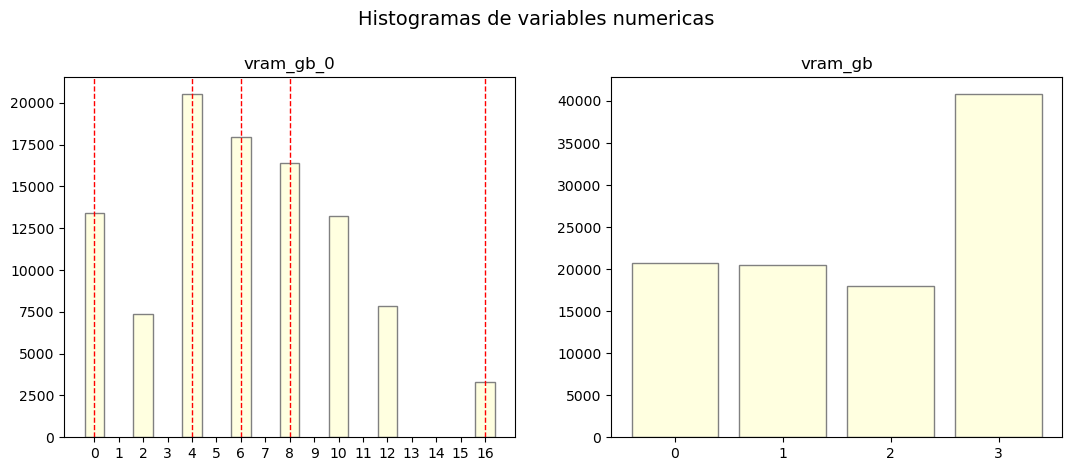

In [8]:
from datetime import datetime


compu_transf = compu_df.copy() #Copiar

#Agregar años desde lanzamiento y eliminar release_year
compu_transf['years_since_release'] = datetime.now().year - compu_transf.release_year
compu_transf.drop(columns = 'release_year', inplace = True)
ColNum = [Col for Col in ColNum if Col not in ['release_year']]
ColNum = ColNum + ['years_since_release']

#discretizar vram_gb
compu_transf['vram_gb_0'] = compu_transf.vram_gb
kb = KBinsDiscretizer(n_bins = 4, strategy = 'quantile', encode = 'ordinal', quantile_method = 'averaged_inverted_cdf')
compu_transf['vram_gb'] = kb.fit_transform(compu_transf[['vram_gb']])
Bins = kb.bin_edges_[0]

#Imprimir
print(f'Bins: {', '.join([str(int(b)) for b in Bins])}')

#Graficar
Fig1 = plt.figure(figsize = (12, 5))
i = 0

for Col in ['vram_gb_0', 'vram_gb']:
    i += 1
    Ax = Fig1.add_subplot(1, 2, i)


    #Grafico de barras
    Counts = compu_transf[Col].value_counts()
    Counts.sort_index(inplace = True)

    Ax.bar(Counts.index, Counts.values, color = 'lightyellow', edgecolor = 'gray') # Histograma normalizado
    x = compu_transf[Col]
    
    #Bins
    if i == 1:
        [Ax.axvline(b, color = 'red', ls = '--', lw = 1) for b in Bins]

    Ax.set_title(Col)
    Ax.set_xticks(range(int(max(x)) + 1))

Fig1.suptitle('Histogramas de variables numericas', fontsize = 14)    
Fig1.tight_layout(pad = 1.0, w_pad = 3, h_pad = 3, rect=[0.05, 0.05, 0.95, 0.98])
plt.show()

compu_transf.drop(columns = 'vram_gb_0', inplace = True)


5. Observa los histogramas del ejercicio 2. Notarás que en las variables `charger_watts` y `psu_watts` aparece una barra en 0. Analiza por qué ocurre esto y qué significa en relación con el tipo de dispositivo.
* Como estas variables son mutuamente excluyentes, combínalas en una nueva columna llamada `power_watts` que contenga la potencia correspondiente de cada dispositivo y, a continuación, haz un histograma para verificar que la distribución resultante es bimodal.
* Por último, borra las columnas originales `charger_watts` y `psu_watts`.


Histogramas:


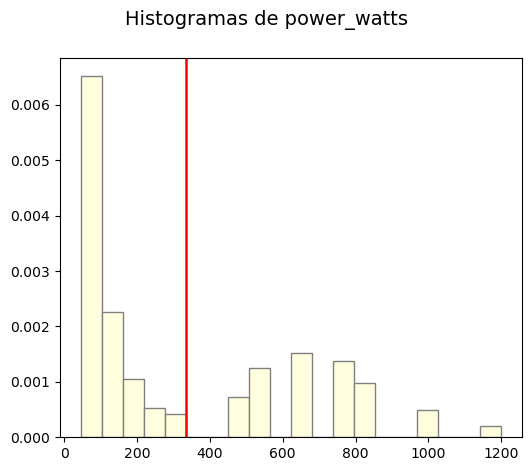

In [9]:
import numpy as np

compu_transf['power_watts'] = np.where(compu_transf.charger_watts > 0, compu_transf.charger_watts, compu_transf.psu_watts)


#Histogramas-------------
print('\nHistogramas:')
Fig1 = plt.figure(figsize = (6, 5))

Ax = Fig1.add_subplot(1, 1, 1)

#Histograma
x = compu_transf['power_watts']
Ax.hist(x, bins = 20, density = True, color = 'lightyellow', edgecolor = 'gray') # Histograma normalizado

#Media
Ax.axvline(x.mean(), color = 'red', ls = '-', lw = 1.8, label = 'Media')

Fig1.suptitle('Histogramas de power_watts', fontsize = 14)    
Fig1.tight_layout(pad = 1.0, w_pad = 3, h_pad = 3, rect=[0.05, 0.05, 0.95, 0.98])
plt.show()

#Eliminar las columnas
compu_transf.drop(columns = ['charger_watts', 'psu_watts'], inplace = True)
ColNum = [Col for Col in ColNum if Col not in ['charger_watts', 'psu_watts']]
ColNum = ColNum + ['power_watts']


6. Para disminuir el sesgo de la variable `price`, crea tres transformadores: logaritmo, raíz cuadrada y Box - Cox.
* Aplica cada transformador a la variable price, dejando el resultado en variables temporales. El objetivo es comparar los efectos de cada transformación antes de decidir cuál aplicar de manera definitiva sobre las variables continuas del dataframe.
* De la variable original y de cada una de las tres transformaciones se debe mostrar:
  * Histograma: para observar la distribución de los datos.
  * Boxplot: para identificar posibles valores atípicos.
  * Q-Q plot: para evaluar la normalidad de la variable.
  * Skew (sesgo): para cuantificar la asimetría de la distribución.
  * Cantidad de outliers: para conocer cuántos valores extremos existen.
* En función de los resultados obtenidos al comparar las transformaciones, decide cuál logró el mejor efecto sobre la distribución de la variable y aplícala directamente en el dataframe, reemplazando las variables continuas: `weight_kg`, `power_watts` y `price`.


Histogramas:


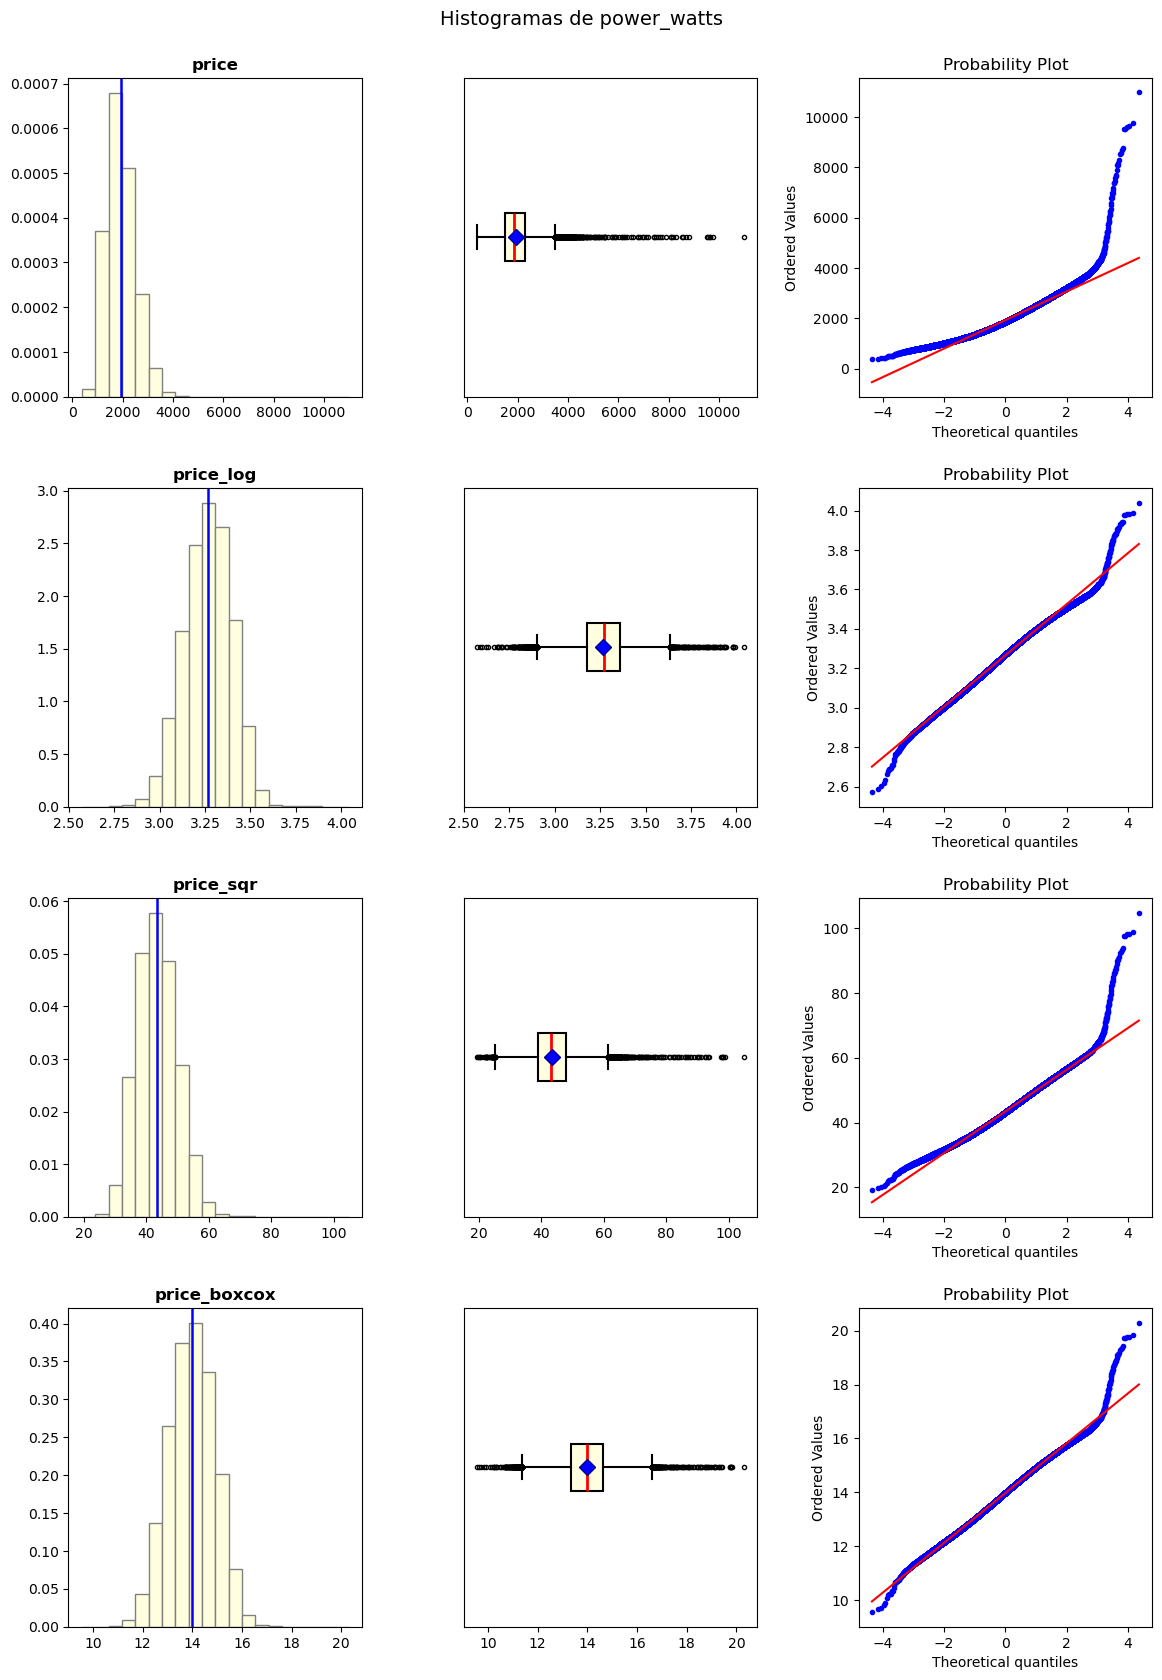

In [10]:
from scipy import stats

compu_transf['price_log'] = np.log10(compu_transf.price)
compu_transf['price_sqr'] = np.sqrt(compu_transf.price)

transformer = PowerTransformer(method = 'box-cox', standardize = False)
compu_transf['price_boxcox'] = transformer.fit_transform(compu_transf[['price']])


print('\nHistogramas:')
i = 0
Fig1 = plt.figure(figsize = (13, 18))
for Col in ['price', 'price_log', 'price_sqr', 'price_boxcox']:

    Ax1 = Fig1.add_subplot(4, 3, 3*i + 1)

    #Histograma
    x = compu_transf[Col]
    Ax1.hist(x, bins = 20, density = True, color = 'lightyellow', edgecolor = 'gray') # Histograma normalizado

    #Media
    Ax1.axvline(x.mean(), color = 'blue', ls = '-', lw = 1.8, label = 'Media')
    Ax1.set_title(Col,  fontweight='bold')

    
    #Boxplot
    Ax2 = Fig1.add_subplot(4, 3, 3*i + 2)
    Ax2.boxplot(compu_transf[Col], vert = False, patch_artist = True, boxprops = dict(facecolor = 'lightyellow', lw = 1.5), medianprops = dict(color = 'red', lw = 2), whiskerprops = dict(color = 'black', lw = 1.5), 
                capprops = dict(color = 'black', lw = 1.5), flierprops = dict(marker = 'o', ms = 3),
                showmeans = True, meanprops = dict(marker = 'D', ms = 8, mfc = 'blue', mec = 'darkblue'))

    Ax2.set_yticks([])
    

    #Boxplot
    Ax3 = Fig1.add_subplot(4, 3, 3*i + 3)
    stats.probplot(compu_transf[Col], dist = 'norm', plot = Ax3)
    Ax3.get_lines()[0].set_markersize(3)

    #Ax3.set_yticks([])
    #Ax3.set_title(Col)

    i += 1

Fig1.suptitle('Histogramas de power_watts', fontsize = 14)    
Fig1.tight_layout(pad = 1.0, w_pad = 2, h_pad = 2, rect=[0.05, 0.05, 0.95, 0.98])
    

plt.show()

7. Para que todas las variables numéricas estén en la misma escala, aplica `MinMaxScaler` de sklearn a todas las columnas numéricas del dataframe, reemplazando las columnas originales.

In [11]:
minmax_scale = MinMaxScaler().fit(compu_transf[ColNum])
compu_transf[ColNum] = minmax_scale.fit_transform(compu_transf[ColNum])

compu_transf

,device_type,brand,os,form_factor,cpu_brand,cpu_tier,cpu_cores,cpu_threads,gpu_brand,gpu_model,...,wifi,bluetooth,weight_kg,warranty_months,price,years_since_release,power_watts,price_log,price_sqr,price_boxcox
0,Desktop,Samsung,Windows,ATX,Intel,0.4,0.333333,0.384615,NVIDIA,RTX 40 60,...,Wi-Fi 6,0.818182,0.668435,0.666667,0.095270,0.428571,0.610390,3.141133,37.202016,13.084411
1,Laptop,Samsung,Windows,Mainstream,Intel,0.6,0.333333,0.384615,NVIDIA,RTX 40 80,...,Wi-Fi 6,1.000000,0.073607,0.000000,0.179231,0.428571,0.064935,3.356979,47.696855,14.616129
2,Desktop,Lenovo,macOS,SFF,AMD,0.2,0.166667,0.230769,NVIDIA,RTX 40 50,...,Wi-Fi 6,0.727273,0.403183,0.333333,0.142009,0.142857,0.696970,3.274156,43.358851,14.014806
3,Desktop,Dell,Windows,ATX,AMD,0.2,0.083333,0.153846,AMD,RX 7000 60,...,Wi-Fi 6,0.909091,0.336870,0.666667,0.090369,0.142857,0.523810,3.124501,36.496438,12.971069
4,Laptop,Gigabyte,Linux,Gaming,AMD,0.8,0.500000,0.538462,NVIDIA,RTX 30 80 Ti,...,Wi-Fi 6,0.909091,0.038462,0.000000,0.217584,0.142857,0.038961,3.428457,51.787933,15.149124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Laptop,ASUS,Windows,Mainstream,Intel,0.6,0.333333,0.384615,AMD,RX 7000 70,...,Wi-Fi 6,0.818182,0.062997,0.333333,0.126272,0.285714,0.116883,3.233755,41.388283,13.727687
99996,Laptop,Lenovo,Windows,Ultrabook,AMD,0.2,0.166667,0.230769,AMD,RX 6000 50,...,Wi-Fi 6,0.818182,0.029841,0.000000,0.083490,1.000000,0.017316,3.100022,35.482249,12.805436
99997,Laptop,ASUS,Windows,Mainstream,Intel,0.2,0.083333,0.115385,NVIDIA,RTX 20 60,...,Wi-Fi 6,0.000000,0.016578,0.000000,0.123822,0.714286,0.116883,3.227113,41.072984,13.680865
99998,Laptop,ASUS,Windows,Mainstream,AMD,0.6,0.333333,0.384615,NVIDIA,RTX 30 70,...,Wi-Fi 6,1.000000,0.051724,0.333333,0.168865,0.714286,0.038961,3.335456,46.529453,14.458200


8. Aunque `wifi` es una variable categórica, sus categorías tienen un orden natural (Wi-Fi 5 < Wi-Fi 6 < Wi-Fi 6E < Wi-Fi 7). Codifícala usando `OrdinalEncoder`.
* Luego, escala la variable codificada entre 0 y 1 con `MinMaxScaler`, para que quede en la misma escala que las variables numéricas del dataframe.

Nota: Ambos cambios deben efectuarse sobre la columna original, de manera que quede una única columna `wifi` con toda la información transformada.

In [12]:
encoder = OrdinalEncoder(categories = [['Wi-Fi 5', 'Wi-Fi 6', 'Wi-Fi 6E', 'Wi-Fi 7']])
compu_transf.wifi = encoder.fit_transform(compu_transf[['wifi']])

minmax_scale = MinMaxScaler().fit(compu_transf[['wifi']])
compu_transf.wifi = minmax_scale.fit_transform(compu_transf[['wifi']])

9. La variable `gpu_model` tiene muchas categorías. Usar *One-Hot Encoding* aumentaría significativamente la dimensionalidad del dataframe. Por ello, utiliza `BinaryEncoder` para codificarla.
* Guarda el resultado en un dataframe llamado `bin_df`. Más adelante, lo combinarás con `compu_transf` para integrar las variables codificadas.

In [13]:
encoder = BinaryEncoder()
bin_df = encoder.fit_transform(compu_transf[['gpu_model']])
bin_df

,gpu_model_0,gpu_model_1,gpu_model_2,gpu_model_3,gpu_model_4,gpu_model_5
0,0,0,0,0,0,1
1,0,0,0,0,1,0
2,0,0,0,0,1,1
3,0,0,0,1,0,0
4,0,0,0,1,0,1
...,...,...,...,...,...,...
99995,1,0,0,0,1,1
99996,0,1,1,0,1,1
99997,1,0,0,0,0,0
99998,0,0,1,0,1,1


10. Usa `OneHotEncoder` para codificar las variables categóricas restantes. Asegúrate de usar `drop='first'` para evitar la multicolinealidad y guarda el resultado en un dataframe llamado `ohe_df`
* Combina el dataframe `compu_transf` con las variables categóricas que fueron codificadas en `bin_df` y `ohe_df`. No olvides eliminar las variables originales.
* Usa `describe()` sobre el dataframe resultante para corroborar que todas las columnas estén escaladas entre 0 y 1 y que no queden variables categóricas sin codificar.

In [ ]:
encoder = OneHotEncoder(drop = 'first')
Cols = [Col for Col in ColNoNum if (Col != 'gpu_model') and (Col != 'wifi')]

ohe_df = pd.DataFrame(
    encoder.fit_transform(compu_transf[Cols]).toarray(),
    columns=encoder.get_feature_names_out(Cols),
    index=compu_transf.index
)
ohe_df

,device_type_Laptop,brand_Acer,brand_Apple,brand_Dell,brand_Gigabyte,brand_HP,brand_Lenovo,brand_MSI,brand_Razer,brand_Samsung,...,gpu_brand_Intel,gpu_brand_NVIDIA,storage_type_Hybrid,storage_type_NVMe,storage_type_SSD,display_type_LED,display_type_Mini-LED,display_type_OLED,display_type_QLED,display_type_VA
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
99996,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
99997,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
99998,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


---

**Declaración de uso de IA**

*   OpenAI. (2026). *ChatGPT (basado en GPT-5.5)* [Modelo de lenguaje grande], utilizado para generación de código, explicación de conceptos y exploración de ideas. https://chat.openai.com/
*   Anthropic. (2026). *Claude Sonnet 4.6* [Modelo de lenguaje grande], utilizado para generación de código, explicación de conceptos y exploración de ideas. https://claude.ai/


---